# VeriPromiseESG 2026 ESG 承諾驗證優化方案
## 5-Fold Stratified K-Fold 交叉驗證 & 多模型 Logits 平均集成 (Ensemble)

本 Notebook 為優化版本的範例程式。主要優化方向包含：
1. **5-Fold Stratified K-Fold 交叉驗證**：根據權重最高且最不均衡的目標欄位 `evidence_quality` 進行分層切分，以確保每一折訓練和驗證的資料分佈一致。
2. **Out-of-Fold (OOF) 評估**：合併 5 折的驗證預測結果，計算出最客觀且泛化能力最佳的 CV 分數。
3. **多模型 Logits 平均集成 (Ensemble)**：將 5 個 Folds 的最佳模型 Logits 平均作為最終 Ensemble 預測，進一步提升 F1 表現與穩定性。
4. **豐富的視覺化分析**：繪製 5 折各自的 Training Loss & Validation Score 曲線，並繪製 4 個任務的 Confusion Matrix。

## Step 1: 載入套件與環境設定

In [1]:
import json
import os
import urllib.request
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 設定中文字型與圖表顯示
matplotlib.rcParams['font.family'] = ['DejaVu Sans', 'Microsoft JhengHei', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

print('套件載入完成！')
print(f'PyTorch 版本: {torch.__version__}')
print(f'CUDA 可用: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU 裝置名稱: {torch.cuda.get_device_name(0)}')


c:\Users\User\Desktop\course\人工智慧\ESG_compitition\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


套件載入完成！
PyTorch 版本: 2.5.1+cu121
CUDA 可用: True
GPU 裝置名稱: NVIDIA GeForce RTX 4060 Ti


## Step 2: 設定超參數與標籤映射

In [2]:
# ============================================================
# 超參數設定
# ============================================================
MODEL_NAME = "bert-base-chinese"   # 或是 "hfl/chinese-roberta-wwm-ext"
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 5
LR = 2e-5
K_FOLDS = 5
TEST_SIZE = 0.2
RANDOM_STATE = 42
FREEZE_BACKBONE = False             # 若 CUDA 不可用而使用 CPU 訓練，設為 True 能凍結 BERT 並加速訓練約 15 倍
STRATIFY_FIELD = "evidence_quality"  # 用來做資料切分的欄位

DATASET_CONFIGS = [
    {
        "name": "final",
        "data_path": "../data/vpesg_4k_train_1000.json",
        "results_dir": "../results/final"
    },
    {
        "name": "final_enhance",
        "data_path": "../data/vpesg_4k_train_1000_enhance.json",
        "results_dir": "../results/final_enhance"
    }
]

for config in DATASET_CONFIGS:
    os.makedirs(config["results_dir"], exist_ok=True)

# 四個預測欄位及其標籤（依照競賽官方規格定義）
EVAL_FIELDS = {
    "promise_status": ["Yes", "No"],
    "verification_timeline": ["already", "within_2_years", "between_2_and_5_years", "more_than_5_years", "N/A"],
    "evidence_status": ["Yes", "No", "N/A"],
    "evidence_quality": ["Clear", "Not Clear", "Misleading", "N/A"]
}

# 各欄位的評分權重（依照競賽規則）
FIELD_WEIGHTS = {
    "promise_status": 0.2,
    "verification_timeline": 0.15,
    "evidence_status": 0.3,
    "evidence_quality": 0.35
}

# 建立標籤與 ID 的對應
label2id = {field: {label: i for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
id2label = {field: {i: label for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
num_labels = {field: len(labels) for field, labels in EVAL_FIELDS.items()}

print('超參數設定完成！')
print(f'使用模型: {MODEL_NAME}')
print(f'交叉驗證折數 (K): {K_FOLDS}')
print(f'Holdout Test 比例: {TEST_SIZE}')
print(f'切分依據欄位: {STRATIFY_FIELD}')
print('本次將依序執行以下資料集設定：')
for config in DATASET_CONFIGS:
    print(f"  - {config['name']}: {config['data_path']} -> {config['results_dir']}")


超參數設定完成！
使用模型: bert-base-chinese
交叉驗證折數 (K): 5
Holdout Test 比例: 0.2
切分依據欄位: evidence_quality
本次將依序執行以下資料集設定：
  - final: ../data/vpesg_4k_train_1000.json -> ../results/final
  - final_enhance: ../data/vpesg_4k_train_1000_enhance.json -> ../results/final_enhance


## Step 3: 載入資料

優先讀取本地的 `data/vpesg_4k_train_1000.json`，若無則從 GitHub 下載。

In [3]:
def resolve_data_path(default_path):
    if os.path.exists(default_path):
        return default_path

    local_name = os.path.basename(default_path)
    if os.path.exists(local_name):
        return local_name

    if local_name == "vpesg_4k_train_1000.json":
        print("本地找不到基礎資料，開始從 GitHub 下載...")
        data_url = "https://raw.githubusercontent.com/veripromiseesg/veripromiseesgdataset/refs/heads/main/vpesg4k_train_1000.json"
        urllib.request.urlretrieve(data_url, local_name)
        print("下載完成！")
        return local_name

    raise FileNotFoundError(f"找不到資料集：{default_path}")


def normalize_label_text(value):
    return "N/A" if value == "" else value


def get_stratify_labels(data, field):
    return [normalize_label_text(sample[field]) for sample in data]


def load_dataset(dataset_path):
    with open(dataset_path, "r", encoding="utf-8") as f:
        return json.load(f)


def split_holdout_data(data, stratify_field, test_size, random_state):
    labels = get_stratify_labels(data, stratify_field)
    label_counts = Counter(labels)
    rare_labels = {label for label, count in label_counts.items() if count < 2}

    desired_test_count = max(1, int(round(len(data) * test_size)))
    if desired_test_count >= len(data):
        desired_test_count = len(data) - 1

    if rare_labels:
        print(f"警告：以下類別樣本數少於 2，無法直接做外層分層切分，將保留在 train/validation：{sorted(rare_labels)}")
        common_data = [sample for sample, label in zip(data, labels) if label not in rare_labels]
        common_labels = [label for label in labels if label not in rare_labels]
        rare_data = [sample for sample, label in zip(data, labels) if label in rare_labels]

        if desired_test_count >= len(common_data):
            raise ValueError("可用於 holdout test 的常見類別樣本不足，無法完成切分。")

        train_val_common, test_data = train_test_split(
            common_data,
            test_size=desired_test_count,
            random_state=random_state,
            shuffle=True,
            stratify=common_labels
        )
        train_val_data = train_val_common + rare_data
        rng = np.random.default_rng(random_state)
        rng.shuffle(train_val_data)
        return train_val_data, test_data

    train_val_data, test_data = train_test_split(
        data,
        test_size=desired_test_count,
        random_state=random_state,
        shuffle=True,
        stratify=labels
    )
    return train_val_data, test_data


print("資料載入與切分輔助函式已準備完成。")


資料載入與切分輔助函式已準備完成。


## Step 4: 建立 PyTorch Dataset 與 DataLoader

In [4]:
class ESGDataset(Dataset):
    def __init__(self, data, tokenizer, label2id):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        text = sample['data']

        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=MAX_LEN,
            padding='max_length',
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        labels = {}
        for field, mapping in self.label2id.items():
            label_text = sample[field]
            if label_text == '':
                label_text = 'N/A'
            labels[field] = torch.tensor(mapping[label_text], dtype=torch.long)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

def collate_fn(batch):
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])
    labels = {
        field: torch.stack([item['labels'][field] for item in batch])
        for field in EVAL_FIELDS
    }
    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels
    }

# 初始化 Tokenizer (採用通用 AutoTokenizer)
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

## Step 5: 模型架構設計

使用 `AutoModel` 以獲得更好的預訓練模型相容性，並加入 Dropout 防止過擬合。

In [5]:
class MultiTaskModel(nn.Module):
    def __init__(self, model_name, num_labels_dict, freeze_backbone=False):
        super().__init__()
        # 載入預訓練 Backbone 模型
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        
        if freeze_backbone:
            for param in self.encoder.parameters():
                param.requires_grad = False
        
        # Dropout 層防止過擬合
        self.dropout = nn.Dropout(0.1)
        
        # 各預測任務的分類頭
        self.classifiers = nn.ModuleDict({
            field: nn.Linear(hidden_size, n)
            for field, n in num_labels_dict.items()
        })

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        
        # 採用 pooler_output ([CLS] 的表示向量)
        pooled = outputs.pooler_output
        pooled = self.dropout(pooled)

        logits = {
            field: clf(pooled)
            for field, clf in self.classifiers.items()
        }
        return logits

## Step 6: 定義訓練、評估與預測函數

In [6]:
def train_one_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    criterion = nn.CrossEntropyLoss()

    for step, batch in enumerate(dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(input_ids, attention_mask)

        loss = sum(
            criterion(logits[field], batch["labels"][field].to(device))
            for field in EVAL_FIELDS
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
    return total_loss / len(dataloader)


def evaluate_hybrid(gt_data, pred_data):
    results = {}
    weighted_score = 0.0

    for field, labels in EVAL_FIELDS.items():
        y_true = [normalize_label_text(item[field]) for item in gt_data]
        y_pred = [normalize_label_text(item[field]) for item in pred_data]

        macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        report = classification_report(y_true, y_pred, labels=labels, zero_division=0)

        weight = FIELD_WEIGHTS.get(field, 0)
        weighted_score += macro_f1 * weight

        results[field] = {
            "macro_f1": macro_f1,
            "micro_f1": micro_f1,
            "report": report,
            "weight": weight
        }

    results["final_weighted_score"] = weighted_score
    return results


def predict(model, dataloader, device, id2label):
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)

            batch_size = input_ids.size(0)
            for i in range(batch_size):
                pred = {}
                for field in EVAL_FIELDS:
                    pred_id = logits[field][i].argmax().item()
                    pred[field] = id2label[field][pred_id]
                predictions.append(pred)
    return predictions


def predict_ensemble(models, dataloader, device, id2label):
    for m in models:
        m.eval()

    ensemble_predictions = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            batch_logits = {field: [] for field in EVAL_FIELDS}
            for model in models:
                logits = model(input_ids, attention_mask)
                for field in EVAL_FIELDS:
                    batch_logits[field].append(logits[field])

            avg_logits = {
                field: torch.stack(batch_logits[field]).mean(dim=0)
                for field in EVAL_FIELDS
            }

            batch_size = input_ids.size(0)
            for i in range(batch_size):
                pred = {}
                for field in EVAL_FIELDS:
                    pred_id = avg_logits[field][i].argmax().item()
                    pred[field] = id2label[field][pred_id]
                ensemble_predictions.append(pred)

    return ensemble_predictions


def get_cv_splitter(labels, n_splits, random_state):
    counts = Counter(labels)
    min_count = min(counts.values())

    if min_count >= n_splits:
        return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state), "StratifiedKFold"

    print(
        f"警告：{STRATIFY_FIELD} 最少類別樣本數只有 {min_count}，不足以支援 {n_splits}-fold stratified split；"
        "此資料集將退回一般 KFold。"
    )
    return KFold(n_splits=n_splits, shuffle=True, random_state=random_state), "KFold"


## Step 7: 5-Fold Stratified K-Fold 交叉驗證訓練迴圈

我們將依據 `evidence_quality` 欄位進行 Stratified K-Fold 切分。對於每一折：
- 訓練模型並評估
- 儲存該折最佳模型至 `results/2026-05-31_kfold_ensemble/best_model_fold_{fold}.pt`
- 收集該折在驗證集上的 Out-of-Fold (OOF) 預測，用於計算整體交叉驗證指標。

使用設備: cuda

開始執行資料集：final
資料路徑：../data/vpesg_4k_train_1000.json
輸出路徑：../results/final
資料載入成功！共 1000 筆資料。
警告：以下類別樣本數少於 2，無法直接做外層分層切分，將保留在 train/validation：['Misleading']
警告：evidence_quality 最少類別樣本數只有 1，不足以支援 5-fold stratified split；此資料集將退回一般 KFold。
Train/Validation 筆數：800
Holdout Test 筆數：200
內層交叉驗證切分器：KFold

========== final | Fold 1 / 5 ==========


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6971.30it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Train Loss: 4.0341 | Val Weighted F1: 0.25714
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.0358 | Val Weighted F1: 0.47866
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.3425 | Val Weighted F1: 0.45432
  Epoch 4/5 | Train Loss: 1.7859 | Val Weighted F1: 0.51319
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.4503 | Val Weighted F1: 0.50090

========== final | Fold 2 / 5 ==========


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10136.58it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Train Loss: 3.8443 | Val Weighted F1: 0.29609
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.2167 | Val Weighted F1: 0.43479
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.4590 | Val Weighted F1: 0.50259
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 1.8204 | Val Weighted F1: 0.46758
  Epoch 5/5 | Train Loss: 1.5018 | Val Weighted F1: 0.51007
    --> 發現更佳模型！已儲存。

========== final | Fold 3 / 5 ==========


...

  Epoch 1/5 | Train Loss: 3.9646 | Val Weighted F1: 0.28844
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.0929 | Val Weighted F1: 0.54018
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.3136 | Val Weighted F1: 0.54542
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 1.7256 | Val Weighted F1: 0.54916
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.4192 | Val Weighted F1: 0.55342
    --> 發現更佳模型！已儲存。

========== final | Fold 4 / 5 ==========


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11509.78it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Train Loss: 4.0276 | Val Weighted F1: 0.35268
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.2304 | Val Weighted F1: 0.45883
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.5688 | Val Weighted F1: 0.47736
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 1.9830 | Val Weighted F1: 0.49415
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.6382 | Val Weighted F1: 0.50119
    --> 發現更佳模型！已儲存。

========== final | Fold 5 / 5 ==========


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10453.98it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Train Loss: 4.1207 | Val Weighted F1: 0.28486
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.2570 | Val Weighted F1: 0.42655
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.6143 | Val Weighted F1: 0.52549
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 2.0387 | Val Weighted F1: 0.52689
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.6966 | Val Weighted F1: 0.51938

final 的 5-Fold 訓練完成，開始輸出圖表與最終評估。


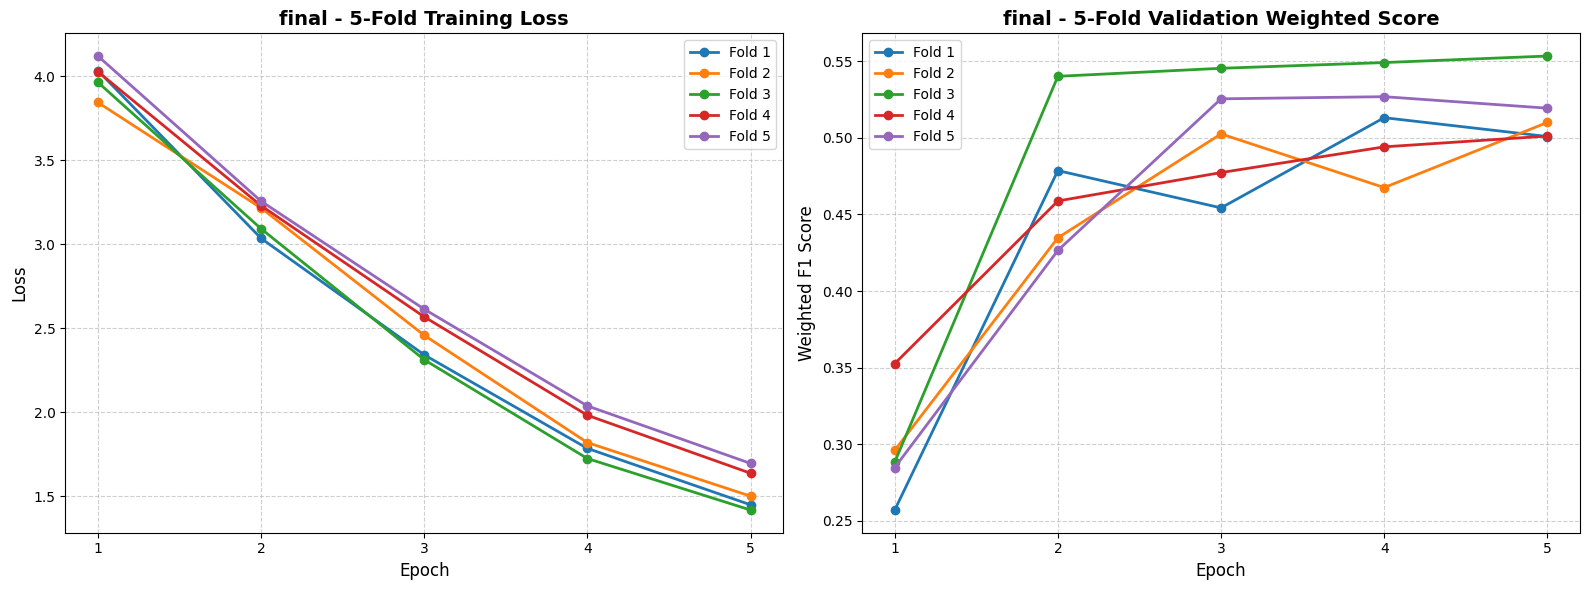

折線圖已儲存至: ../results/final\training_curves.png


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10436.20it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12042.51it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  

成功載入 5 個 Fold 的最佳模型權重！

【1】OOF 交叉驗證加權分數 (final): 0.52440
【2】Holdout Test Ensemble 加權分數 (final): 0.59061

--- OOF 各欄位詳細指標 ---
  promise_status (w=0.2): Macro F1 = 0.7360 | Micro F1 = 0.8700
  verification_timeline (w=0.15): Macro F1 = 0.4294 | Micro F1 = 0.5375
  evidence_status (w=0.3): Macro F1 = 0.5870 | Micro F1 = 0.7488
  evidence_quality (w=0.35): Macro F1 = 0.3905 | Micro F1 = 0.6637

--- Holdout Test 各欄位詳細指標 ---
  promise_status (w=0.2): Macro F1 = 0.7905 | Micro F1 = 0.8750
  verification_timeline (w=0.15): Macro F1 = 0.4373 | Micro F1 = 0.5550
  evidence_status (w=0.3): Macro F1 = 0.6379 | Micro F1 = 0.7750
  evidence_quality (w=0.35): Macro F1 = 0.5016 | Micro F1 = 0.7600


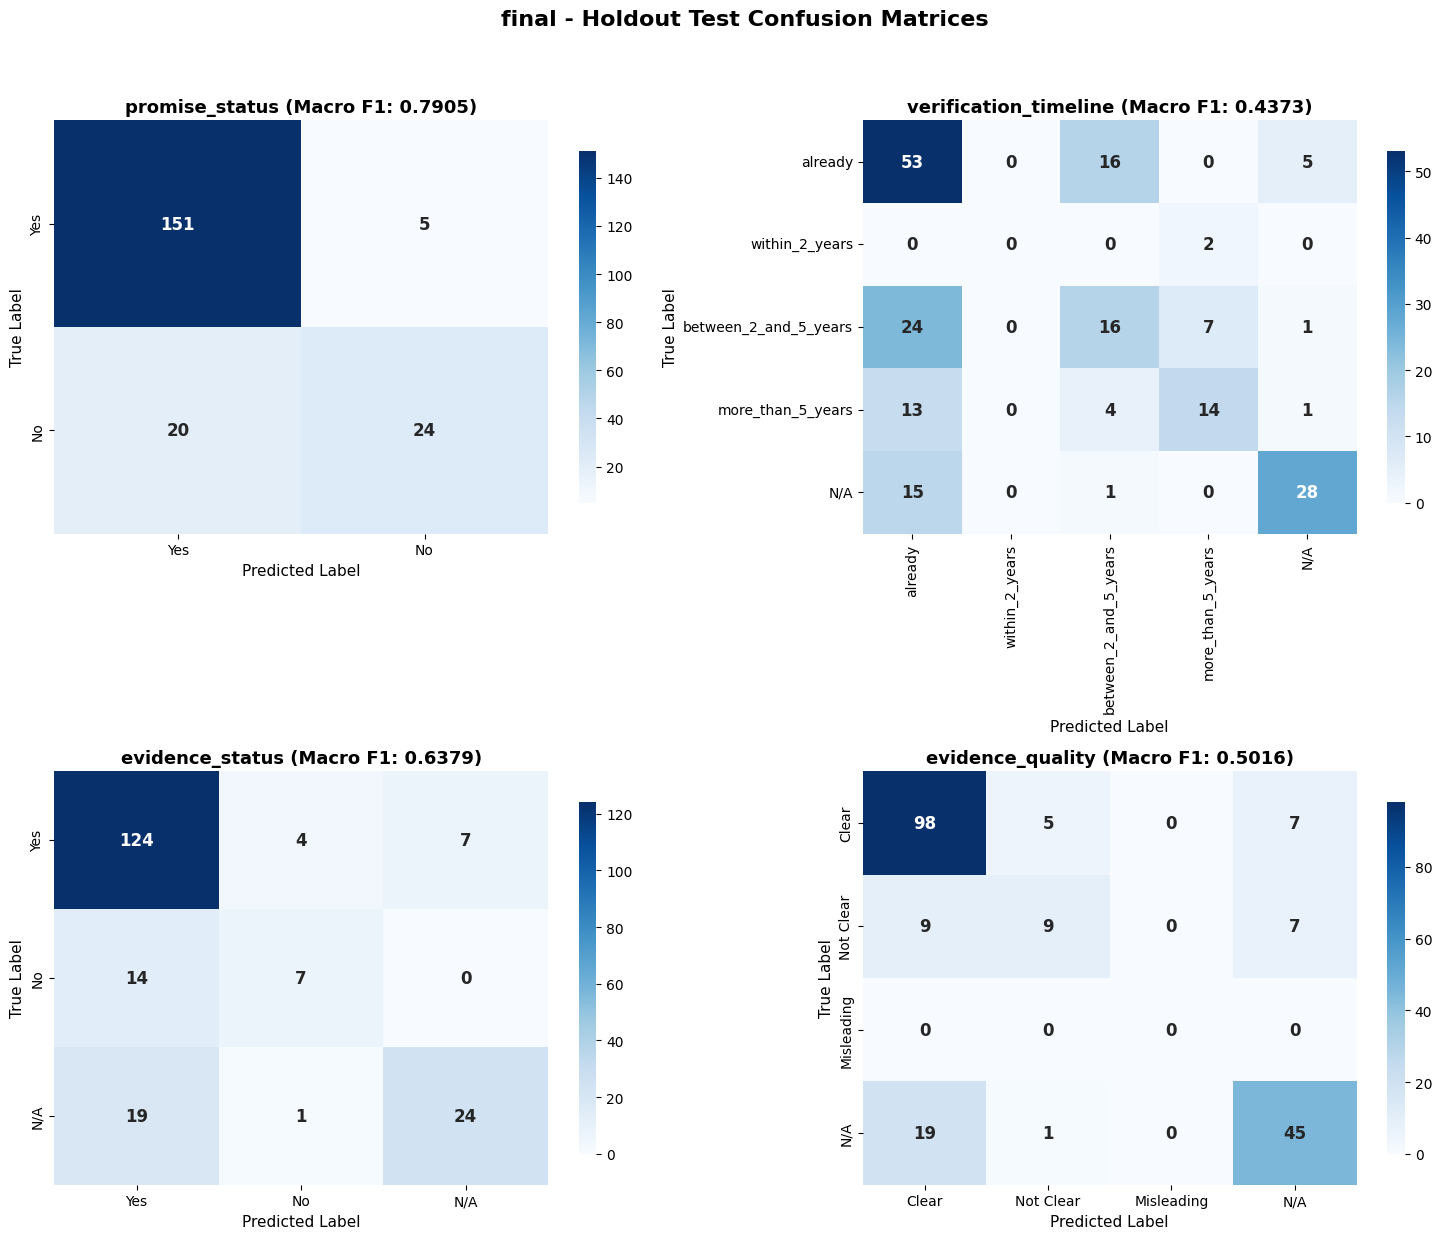

混淆矩陣熱力圖已儲存至: ../results/final\confusion_matrices.png
超參數已寫入: ../results/final\config.json
評估指標已寫入: ../results/final\metrics.json
最終預測數據已寫入: ../results/final\prediction.json

開始執行資料集：final_enhance
資料路徑：../data/vpesg_4k_train_1000_enhance.json
輸出路徑：../results/final_enhance
資料載入成功！共 1250 筆資料。
Train/Validation 筆數：1000
Holdout Test 筆數：250
內層交叉驗證切分器：StratifiedKFold

========== final_enhance | Fold 1 / 5 ==========


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10460.27it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Train Loss: 3.9482 | Val Weighted F1: 0.36450
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.0481 | Val Weighted F1: 0.41001
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.3183 | Val Weighted F1: 0.56867
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 1.7698 | Val Weighted F1: 0.58519
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.4763 | Val Weighted F1: 0.62397
    --> 發現更佳模型！已儲存。

========== final_enhance | Fold 2 / 5 ==========


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11599.20it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Train Loss: 4.0565 | Val Weighted F1: 0.31205
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.2382 | Val Weighted F1: 0.46363
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.4781 | Val Weighted F1: 0.50307
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 1.9548 | Val Weighted F1: 0.61064
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.6644 | Val Weighted F1: 0.62435
    --> 發現更佳模型！已儲存。

========== final_enhance | Fold 3 / 5 ==========


...

  Epoch 1/5 | Train Loss: 3.9669 | Val Weighted F1: 0.35984
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.0967 | Val Weighted F1: 0.54787
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.4125 | Val Weighted F1: 0.57678
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 1.9055 | Val Weighted F1: 0.62132
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.5763 | Val Weighted F1: 0.63493
    --> 發現更佳模型！已儲存。

========== final_enhance | Fold 4 / 5 ==========


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11357.40it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Train Loss: 4.0866 | Val Weighted F1: 0.33696
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.0960 | Val Weighted F1: 0.53013
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.3405 | Val Weighted F1: 0.55866
    --> 發現更佳模型！已儲存。
  Epoch 4/5 | Train Loss: 1.7671 | Val Weighted F1: 0.59317
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.4440 | Val Weighted F1: 0.60641
    --> 發現更佳模型！已儲存。

========== final_enhance | Fold 5 / 5 ==========


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9932.72it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/5 | Train Loss: 3.9691 | Val Weighted F1: 0.32098
    --> 發現更佳模型！已儲存。
  Epoch 2/5 | Train Loss: 3.0518 | Val Weighted F1: 0.53277
    --> 發現更佳模型！已儲存。
  Epoch 3/5 | Train Loss: 2.2863 | Val Weighted F1: 0.47187
  Epoch 4/5 | Train Loss: 1.8121 | Val Weighted F1: 0.57568
    --> 發現更佳模型！已儲存。
  Epoch 5/5 | Train Loss: 1.5187 | Val Weighted F1: 0.57767
    --> 發現更佳模型！已儲存。

final_enhance 的 5-Fold 訓練完成，開始輸出圖表與最終評估。


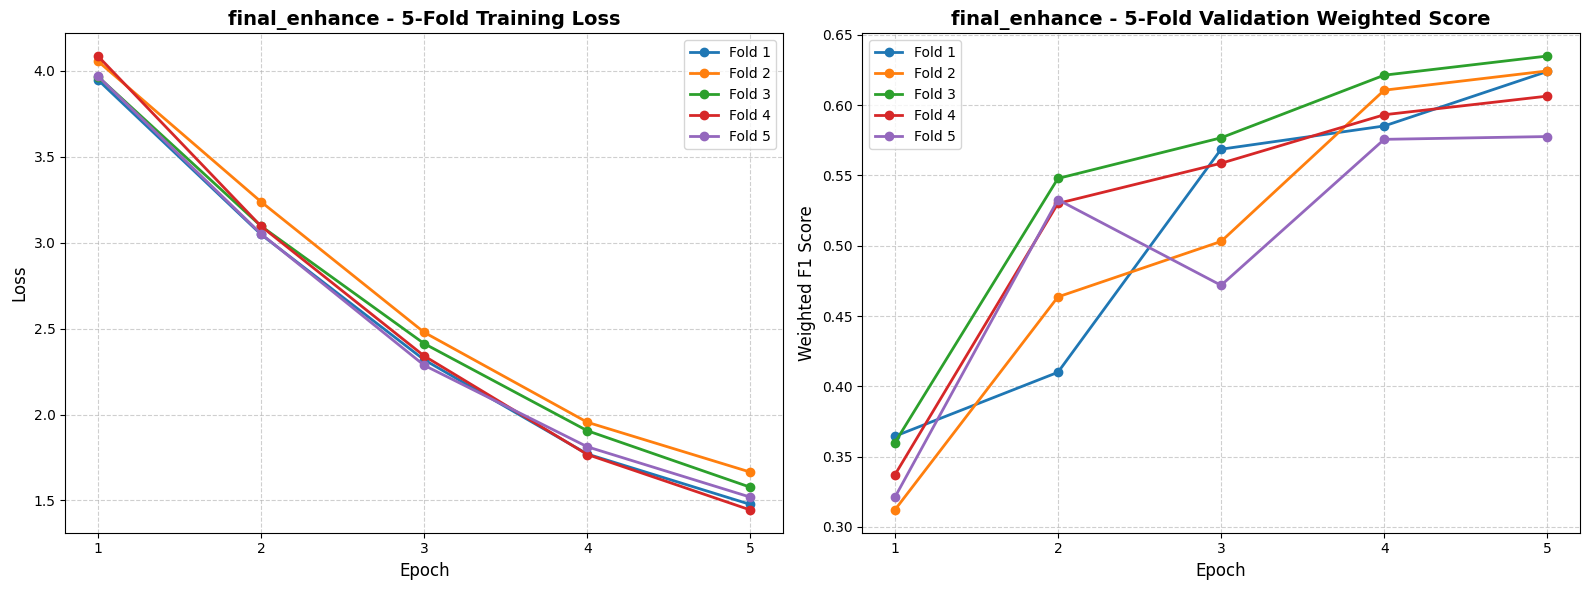

折線圖已儲存至: ../results/final_enhance\training_curves.png


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10737.75it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9933.19it/s]
[transformers] BertModel LOAD REPORT from: bert-base-chinese
Key                                        | Status     |  |

成功載入 5 個 Fold 的最佳模型權重！

【1】OOF 交叉驗證加權分數 (final_enhance): 0.61546
【2】Holdout Test Ensemble 加權分數 (final_enhance): 0.62097

--- OOF 各欄位詳細指標 ---
  promise_status (w=0.2): Macro F1 = 0.8051 | Micro F1 = 0.9070
  verification_timeline (w=0.15): Macro F1 = 0.6252 | Micro F1 = 0.5990
  evidence_status (w=0.3): Macro F1 = 0.6386 | Micro F1 = 0.8020
  evidence_quality (w=0.35): Macro F1 = 0.4831 | Micro F1 = 0.6500

--- Holdout Test 各欄位詳細指標 ---
  promise_status (w=0.2): Macro F1 = 0.7905 | Micro F1 = 0.9040
  verification_timeline (w=0.15): Macro F1 = 0.6293 | Micro F1 = 0.6080
  evidence_status (w=0.3): Macro F1 = 0.6531 | Micro F1 = 0.8040
  evidence_quality (w=0.35): Macro F1 = 0.4929 | Micro F1 = 0.6720


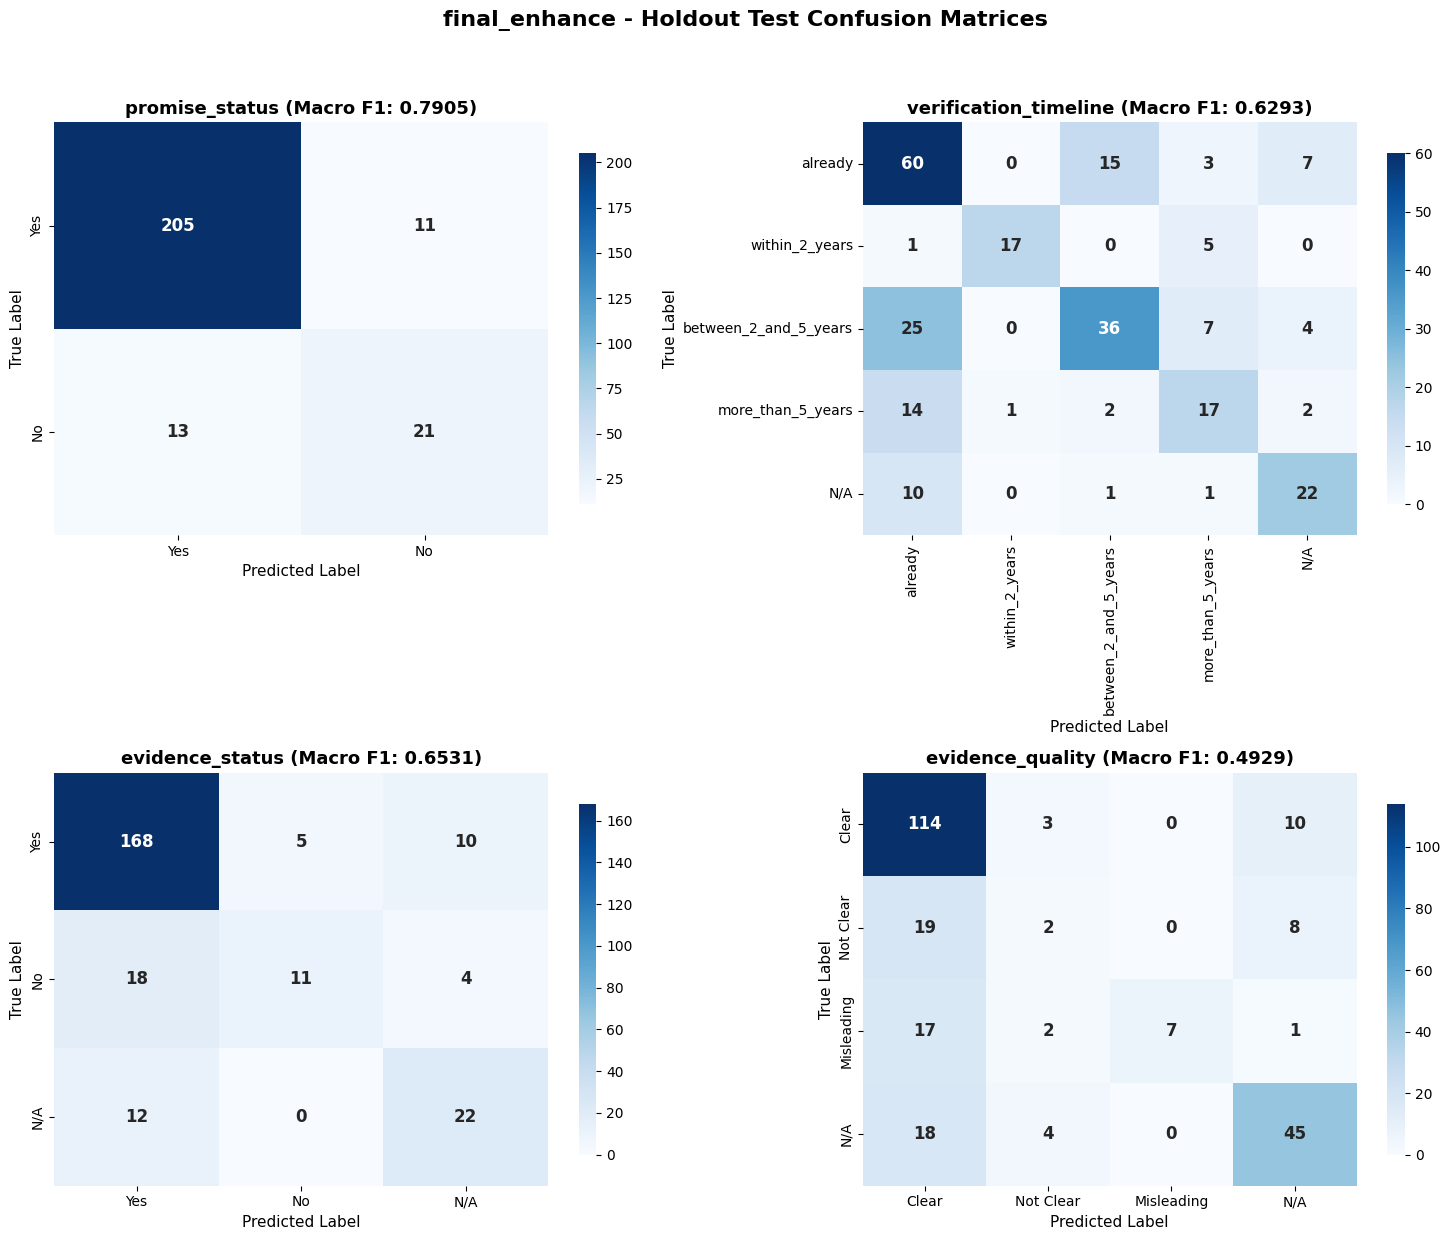

混淆矩陣熱力圖已儲存至: ../results/final_enhance\confusion_matrices.png
超參數已寫入: ../results/final_enhance\config.json
評估指標已寫入: ../results/final_enhance\metrics.json
最終預測數據已寫入: ../results/final_enhance\prediction.json

所有資料集流程執行完畢，摘要如下：
- final: OOF=0.52440, Holdout Test=0.59061, 輸出目錄=../results/final
- final_enhance: OOF=0.61546, Holdout Test=0.62097, 輸出目錄=../results/final_enhance


In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用設備: {device}")

experiment_results = {}

for dataset_config in DATASET_CONFIGS:
    dataset_name = dataset_config["name"]
    results_dir = dataset_config["results_dir"]
    data_path = resolve_data_path(dataset_config["data_path"])

    print("\n" + "=" * 80)
    print(f"開始執行資料集：{dataset_name}")
    print(f"資料路徑：{data_path}")
    print(f"輸出路徑：{results_dir}")
    print("=" * 80)

    all_data = load_dataset(data_path)
    print(f"資料載入成功！共 {len(all_data)} 筆資料。")

    train_val_data, test_data = split_holdout_data(
        all_data,
        stratify_field=STRATIFY_FIELD,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE
    )
    train_val_labels = get_stratify_labels(train_val_data, STRATIFY_FIELD)
    cv_splitter, cv_splitter_name = get_cv_splitter(train_val_labels, K_FOLDS, RANDOM_STATE)

    print(f"Train/Validation 筆數：{len(train_val_data)}")
    print(f"Holdout Test 筆數：{len(test_data)}")
    print(f"內層交叉驗證切分器：{cv_splitter_name}")

    fold_histories = []
    oof_predictions = [None] * len(train_val_data)

    if cv_splitter_name == "StratifiedKFold":
        split_iterator = cv_splitter.split(train_val_data, train_val_labels)
    else:
        split_iterator = cv_splitter.split(train_val_data)

    for fold, (train_idx, val_idx) in enumerate(split_iterator):
        print(f"\n========== {dataset_name} | Fold {fold + 1} / {K_FOLDS} ==========")

        fold_train_data = [train_val_data[i] for i in train_idx]
        fold_val_data = [train_val_data[i] for i in val_idx]

        train_dataset = ESGDataset(fold_train_data, tokenizer, label2id)
        val_dataset = ESGDataset(fold_val_data, tokenizer, label2id)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

        model = MultiTaskModel(MODEL_NAME, num_labels, freeze_backbone=FREEZE_BACKBONE).to(device)
        optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

        total_steps = len(train_loader) * EPOCHS
        warmup_steps = int(0.1 * total_steps)
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )

        best_score = float("-inf")
        best_val_preds = None
        history = {"train_loss": [], "val_score": []}

        model_save_path = os.path.join(results_dir, f"best_model_fold_{fold}.pt")

        for epoch in range(EPOCHS):
            avg_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device)
            history["train_loss"].append(avg_loss)

            val_preds = predict(model, val_loader, device, id2label)
            val_results = evaluate_hybrid(fold_val_data, val_preds)
            current_score = val_results["final_weighted_score"]
            history["val_score"].append(current_score)

            print(f"  Epoch {epoch + 1}/{EPOCHS} | Train Loss: {avg_loss:.4f} | Val Weighted F1: {current_score:.5f}")

            if current_score > best_score:
                best_score = current_score
                torch.save(model.state_dict(), model_save_path)
                best_val_preds = val_preds
                print("    --> 發現更佳模型！已儲存。")

        if best_val_preds is None:
            raise RuntimeError(f"{dataset_name} fold {fold} 未產生最佳驗證預測結果。")

        fold_histories.append(history)

        for idx, val_pos in enumerate(val_idx):
            oof_predictions[val_pos] = best_val_preds[idx]

    if any(pred is None for pred in oof_predictions):
        raise RuntimeError(f"{dataset_name} 的 OOF 預測未完整覆蓋 train/validation 資料。")

    print(f"\n{dataset_name} 的 {K_FOLDS}-Fold 訓練完成，開始輸出圖表與最終評估。")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    epochs_range = range(1, EPOCHS + 1)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for fold in range(K_FOLDS):
        axes[0].plot(
            epochs_range,
            fold_histories[fold]["train_loss"],
            '-o',
            label=f'Fold {fold + 1}',
            color=colors[fold % len(colors)],
            linewidth=2
        )
    axes[0].set_title(f"{dataset_name} - {K_FOLDS}-Fold Training Loss", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Epoch", fontsize=12)
    axes[0].set_ylabel("Loss", fontsize=12)
    axes[0].set_xticks(list(epochs_range))
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend(fontsize=10)

    for fold in range(K_FOLDS):
        axes[1].plot(
            epochs_range,
            fold_histories[fold]["val_score"],
            '-o',
            label=f'Fold {fold + 1}',
            color=colors[fold % len(colors)],
            linewidth=2
        )
    axes[1].set_title(f"{dataset_name} - {K_FOLDS}-Fold Validation Weighted Score", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Epoch", fontsize=12)
    axes[1].set_ylabel("Weighted F1 Score", fontsize=12)
    axes[1].set_xticks(list(epochs_range))
    axes[1].grid(True, linestyle='--', alpha=0.6)
    axes[1].legend(fontsize=10)

    plt.tight_layout()
    training_curve_path = os.path.join(results_dir, "training_curves.png")
    plt.savefig(training_curve_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"折線圖已儲存至: {training_curve_path}")

    models = []
    for fold in range(K_FOLDS):
        model = MultiTaskModel(MODEL_NAME, num_labels, freeze_backbone=FREEZE_BACKBONE).to(device)
        model_save_path = os.path.join(results_dir, f"best_model_fold_{fold}.pt")
        model.load_state_dict(torch.load(model_save_path, map_location=device))
        models.append(model)
    print(f"成功載入 {len(models)} 個 Fold 的最佳模型權重！")

    test_dataset = ESGDataset(test_data, tokenizer, label2id)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    oof_results = evaluate_hybrid(train_val_data, oof_predictions)
    test_preds = predict_ensemble(models, test_loader, device, id2label)
    test_results = evaluate_hybrid(test_data, test_preds)

    print("\n" + "=" * 60)
    print(f"【1】OOF 交叉驗證加權分數 ({dataset_name}): {oof_results['final_weighted_score']:.5f}")
    print(f"【2】Holdout Test Ensemble 加權分數 ({dataset_name}): {test_results['final_weighted_score']:.5f}")
    print("=" * 60)

    print("\n--- OOF 各欄位詳細指標 ---")
    for field in EVAL_FIELDS:
        r = oof_results[field]
        print(f"  {field} (w={r['weight']}): Macro F1 = {r['macro_f1']:.4f} | Micro F1 = {r['micro_f1']:.4f}")

    print("\n--- Holdout Test 各欄位詳細指標 ---")
    for field in EVAL_FIELDS:
        r = test_results[field]
        print(f"  {field} (w={r['weight']}): Macro F1 = {r['macro_f1']:.4f} | Micro F1 = {r['micro_f1']:.4f}")

    fig, axes = plt.subplots(2, 2, figsize=(15, 13))
    fig.suptitle(f"{dataset_name} - Holdout Test Confusion Matrices", fontsize=16, fontweight='bold', y=0.95)

    for idx, (field, labels) in enumerate(EVAL_FIELDS.items()):
        ax = axes[idx // 2][idx % 2]
        y_true = [normalize_label_text(item[field]) for item in test_data]
        y_pred = [normalize_label_text(item[field]) for item in test_preds]

        cm = confusion_matrix(y_true, y_pred, labels=labels)
        sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax,
            xticklabels=labels,
            yticklabels=labels,
            annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'shrink': 0.85}
        )
        ax.set_title(f"{field} (Macro F1: {test_results[field]['macro_f1']:.4f})", fontsize=13, fontweight='bold')
        ax.set_xlabel("Predicted Label", fontsize=11)
        ax.set_ylabel("True Label", fontsize=11)
        ax.tick_params(axis='both', which='major', labelsize=10)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    confusion_matrix_path = os.path.join(results_dir, "confusion_matrices.png")
    plt.savefig(confusion_matrix_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"混淆矩陣熱力圖已儲存至: {confusion_matrix_path}")

    config_data = {
        "dataset_name": dataset_name,
        "dataset_path": data_path,
        "results_dir": results_dir,
        "model_name": MODEL_NAME,
        "max_len": MAX_LEN,
        "batch_size": BATCH_SIZE,
        "epochs_per_fold": EPOCHS,
        "learning_rate": LR,
        "k_folds": K_FOLDS,
        "holdout_test_ratio": TEST_SIZE,
        "random_state": RANDOM_STATE,
        "stratify_by_field": STRATIFY_FIELD,
        "cv_splitter": cv_splitter_name,
        "train_val_size": len(train_val_data),
        "test_size": len(test_data)
    }
    config_path = os.path.join(results_dir, "config.json")
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(config_data, f, ensure_ascii=False, indent=2)
    print(f"超參數已寫入: {config_path}")

    metrics_data = {
        "oof_weighted_f1": oof_results["final_weighted_score"],
        "holdout_test_weighted_f1": test_results["final_weighted_score"],
        "oof_detailed": {
            field: {
                "macro_f1": oof_results[field]["macro_f1"],
                "micro_f1": oof_results[field]["micro_f1"]
            } for field in EVAL_FIELDS
        },
        "holdout_test_detailed": {
            field: {
                "macro_f1": test_results[field]["macro_f1"],
                "micro_f1": test_results[field]["micro_f1"]
            } for field in EVAL_FIELDS
        }
    }
    metrics_path = os.path.join(results_dir, "metrics.json")
    with open(metrics_path, "w", encoding="utf-8") as f:
        json.dump(metrics_data, f, ensure_ascii=False, indent=2)
    print(f"評估指標已寫入: {metrics_path}")

    output_data = []
    for orig, pred in zip(test_data, test_preds):
        item = dict(orig)
        item["split"] = "holdout_test"
        for field in EVAL_FIELDS:
            item[f"pred_{field}"] = pred[field]
        output_data.append(item)

    prediction_path = os.path.join(results_dir, "prediction.json")
    with open(prediction_path, "w", encoding="utf-8") as f:
        json.dump(output_data, f, ensure_ascii=False, indent=2)
    print(f"最終預測數據已寫入: {prediction_path}")

    experiment_results[dataset_name] = {
        "data_path": data_path,
        "results_dir": results_dir,
        "train_val_size": len(train_val_data),
        "test_size": len(test_data),
        "cv_splitter": cv_splitter_name,
        "oof_weighted_f1": oof_results["final_weighted_score"],
        "holdout_test_weighted_f1": test_results["final_weighted_score"],
        "training_curve_path": training_curve_path,
        "confusion_matrix_path": confusion_matrix_path,
        "config_path": config_path,
        "metrics_path": metrics_path,
        "prediction_path": prediction_path
    }

print("\n所有資料集流程執行完畢，摘要如下：")
for dataset_name, summary in experiment_results.items():
    print(
        f"- {dataset_name}: OOF={summary['oof_weighted_f1']:.5f}, "
        f"Holdout Test={summary['holdout_test_weighted_f1']:.5f}, "
        f"輸出目錄={summary['results_dir']}"
    )


## Step 8: 繪製訓練折線圖

In [8]:
print("主流程、折線圖與最終評估已整合到上一個 cell；請直接執行上方主流程。")


主流程、折線圖與最終評估已整合到上一個 cell；請直接執行上方主流程。


## Step 9: 實作 Ensemble (多模型 Logits 平均集成) 預測

我們將實作一個預測函數，讀入 5 折的所有模型，並將 5 個模型對同一筆輸入產生的 Logits 進行平均，再取最高分作為預測結果。這通常能大幅增強泛化能力並提升 F1 分數。

In [9]:
print("Ensemble 預測函式已移至前方的函式定義 cell。")


Ensemble 預測函式已移至前方的函式定義 cell。


## Step 10: 載入最佳模型進行預測評估

In [10]:
print("模型載入與 Holdout Test 評估已整合到主流程 cell。")


模型載入與 Holdout Test 評估已整合到主流程 cell。


## Step 11: 繪製混淆矩陣 (Confusion Matrix)

In [11]:
print("混淆矩陣輸出已整合到主流程 cell。")


混淆矩陣輸出已整合到主流程 cell。


## Step 12: 儲存評估結果與超參數設定

In [12]:
print("config / metrics / prediction 輸出已整合到主流程 cell。")


config / metrics / prediction 輸出已整合到主流程 cell。
